### Applied Partial Differential Equations | Richard Haberman | Solutions and Code by David A. Lee
### Chapter 3: Fourier Series
#### Section 3.3: Fourier Cosine and Sine Series

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import scienceplots

Question 3.3.1

In [2]:
def style_ax(ax, xlabel='$x$', ylabel='$y$', xlim=None, ylim=None,
             xticks=None, xticklabels=None, yticks=None, yticklabels=None,
             color='white', fontsize=16):
    """Apply shared plot attributes to one or more axes."""
    axes = np.atleast_1d(ax)
    for a in axes:
        a.set_xlabel(xlabel, color=color, fontsize=fontsize)
        a.set_ylabel(ylabel, color=color, fontsize=fontsize)
        a.tick_params(colors=color)
        a.tick_params(labelsize=fontsize)
        a.tick_params(which='minor', top=False, bottom=False, left=False, right=False)
        a.grid(False)
        if xlim is not None:
            a.set_xlim(xlim)
        if ylim is not None:
            a.set_ylim(ylim)
        if xticks is not None:
            a.set_xticks(xticks)
        if xticklabels is not None:
            a.set_xticklabels(xticklabels, color=color)
        if yticks is not None:
            a.set_yticks(yticks)
        if yticklabels is not None:
            a.set_yticklabels(yticklabels, color=color)

In [3]:
L = 1.0
PERIODS = range(-2, 2)   # copies of (-L, L) covering [-3L, 3L]

L_ticks = [-3*L, -2*L, -L, 0, L, 2*L, 3*L]
L_labels = [r'$-3L$', r'$-2L$', r'$-L$', r'$0$', r'$L$', r'$2L$', r'$3L$']


def split_at_zero(pieces):
    """Ensure x = 0 is a piece boundary so the (0, L) half can be extracted."""
    out = []
    for a, b, g in pieces:
        if a < 0 < b:
            out += [(a, 0.0, g), (0.0, b, g)]
        else:
            out.append((a, b, g))
    return out


def odd_extension(pieces):
    """Fourier sine series converges to the odd, 2L-periodic extension of f on (0, L)."""
    right = [(a, b, g) for a, b, g in split_at_zero(pieces) if a >= 0]
    return [(-b, -a, (lambda g: lambda x: -g(-x))(g)) for a, b, g in right] + right


def even_extension(pieces):
    """Fourier cosine series converges to the even, 2L-periodic extension of f on (0, L)."""
    right = [(a, b, g) for a, b, g in split_at_zero(pieces) if a >= 0]
    return [(-b, -a, (lambda g: lambda x: g(-x))(g)) for a, b, g in right] + right


def draw_periodic(ax, pieces, color, label):
    """2L-periodic extension of pieces on [-3L, 3L], with jump markers
    (open circles = one-sided limits, filled dot = midpoint the series converges to)."""
    vals = []
    for k in PERIODS:
        for a, b, g in pieces:
            x = np.linspace(a, b, 400)
            y = g(x)
            vals.append(y)
            ax.plot(x + 2*k*L, y, color=color, linewidth=2.5)
    ax.plot([], [], color=color, linewidth=2.5, label=label)

    lefts  = {b: g(b) for a, b, g in pieces}   # limit from the left at x = b
    rights = {a: g(a) for a, b, g in pieces}   # limit from the right at x = a
    lefts[-L], rights[L] = lefts[L], rights[-L]  # periodicity wraps the ends
    for x0 in sorted(rights):
        lo, hi = lefts[x0], rights[x0]
        if not np.isclose(lo, hi):
            for k in PERIODS:
                xs = x0 + 2*k*L
                if -3*L <= xs <= 3*L:
                    ax.plot([xs, xs], [lo, hi], color=color, linestyle=':', linewidth=1)
                    ax.plot([xs, xs], [lo, hi], 'o', color='black', markeredgecolor=color, markersize=6)
                    ax.plot(xs, (lo + hi)/2, 'o', color=color, markersize=6)
    return np.concatenate(vals)


def plot_all_series(pieces, label, fname, colors):
    """Rows: f on [-L, L]; Fourier series; Fourier sine series; Fourier cosine series."""
    plt.style.use(['science', 'scatter', 'dark_background'])
    fig, ax = plt.subplots(4, 1, figsize=(14, 13), sharex=True)

    # row 0: f itself, only on [-L, L]
    vals = []
    for a, b, g in pieces:
        x = np.linspace(a, b, 400)
        y = g(x)
        vals.append(y)
        ax[0].plot(x, y, color=colors[0], linewidth=2.5)
    ax[0].plot([], [], color=colors[0], linewidth=2.5, label=label)

    # rows 1-3: the three periodic extensions
    vals.append(draw_periodic(ax[1], pieces, colors[1], 'Fourier series'))
    vals.append(draw_periodic(ax[2], odd_extension(pieces), colors[2], 'Fourier sine series'))
    vals.append(draw_periodic(ax[3], even_extension(pieces), colors[3], 'Fourier cosine series'))

    v = np.concatenate(vals)
    pad = 0.15*(v.max() - v.min() or 1)
    ylim = (v.min() - pad, v.max() + pad)
    style_ax(ax, xlabel='', ylabel='', xlim=(-3*L, 3*L), ylim=ylim,
             xticks=L_ticks, xticklabels=L_labels)
    ax[0].set_ylabel('$f(x)$', color='white', fontsize=16)
    ax[3].set_xlabel('$x$', color='white', fontsize=16)
    for a in ax:
        a.axhline(0, color='white', linestyle='--', linewidth=1)
        for k in range(-3, 4, 2):
            a.axvline(k*L, color='white', linestyle='--', linewidth=1)
        a.legend(frameon=True, fontsize=14, loc='lower right', bbox_to_anchor=(1, 1.0))

    fig.subplots_adjust(hspace=0.35)
    fig.savefig(fname, format='pdf')
    plt.show()

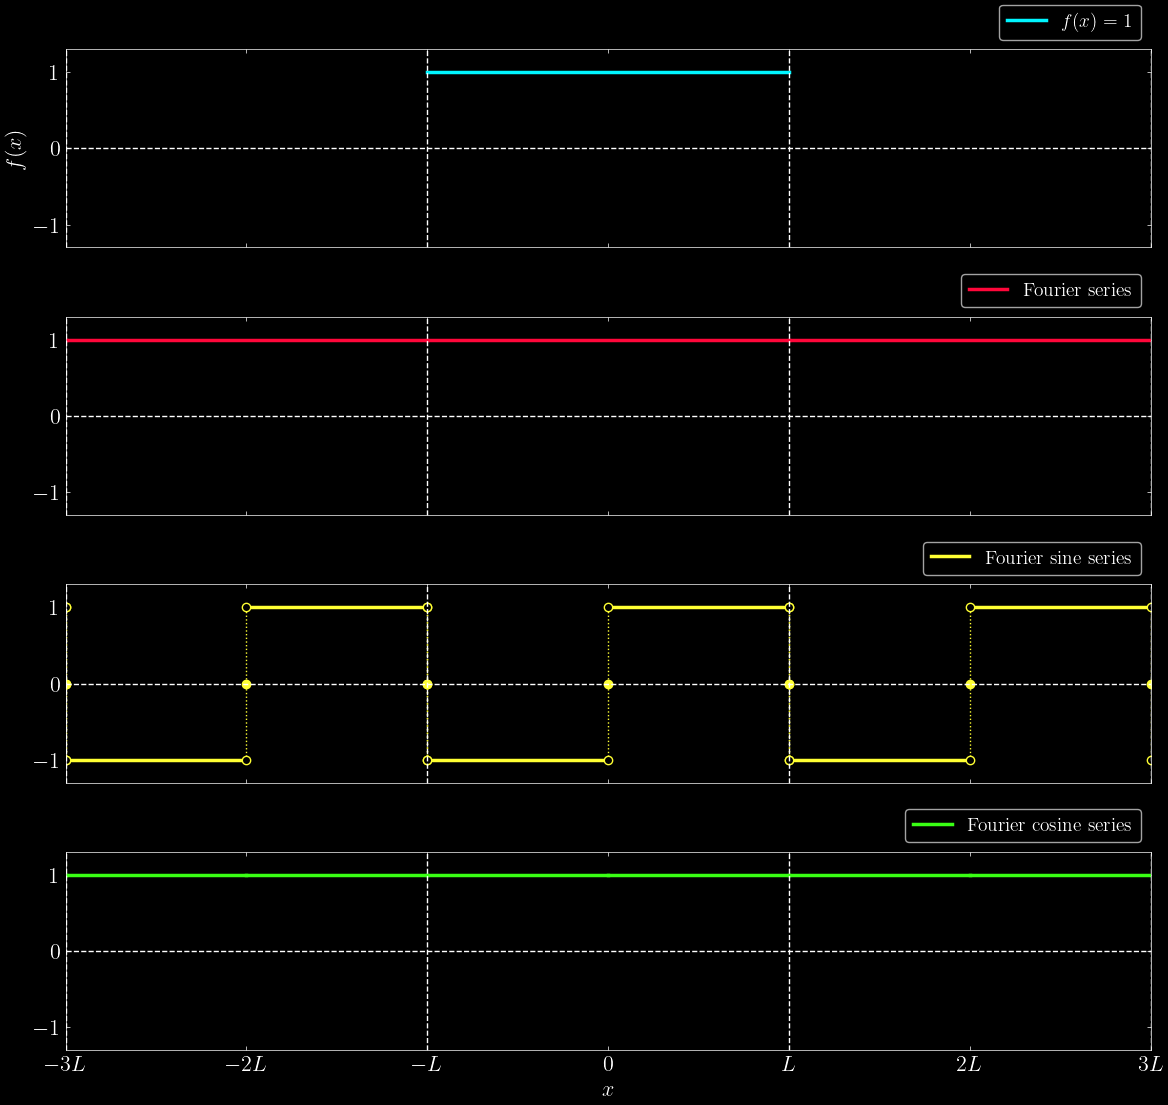

In [4]:
pieces = [(-L, L, lambda x: np.ones_like(x))]
plot_all_series(pieces, r"$f(x) = 1$", "chap3sec3.3ex1a.pdf", ['#00F5FF', '#FF073A', '#FFFF33', '#39FF14'])

(a) Fourier and cosine series: constant $1$ everywhere. Sine series: odd square wave, $\pm 1$, converging to $0$ at $x = 0, \pm L, \pm 2L, \ldots$

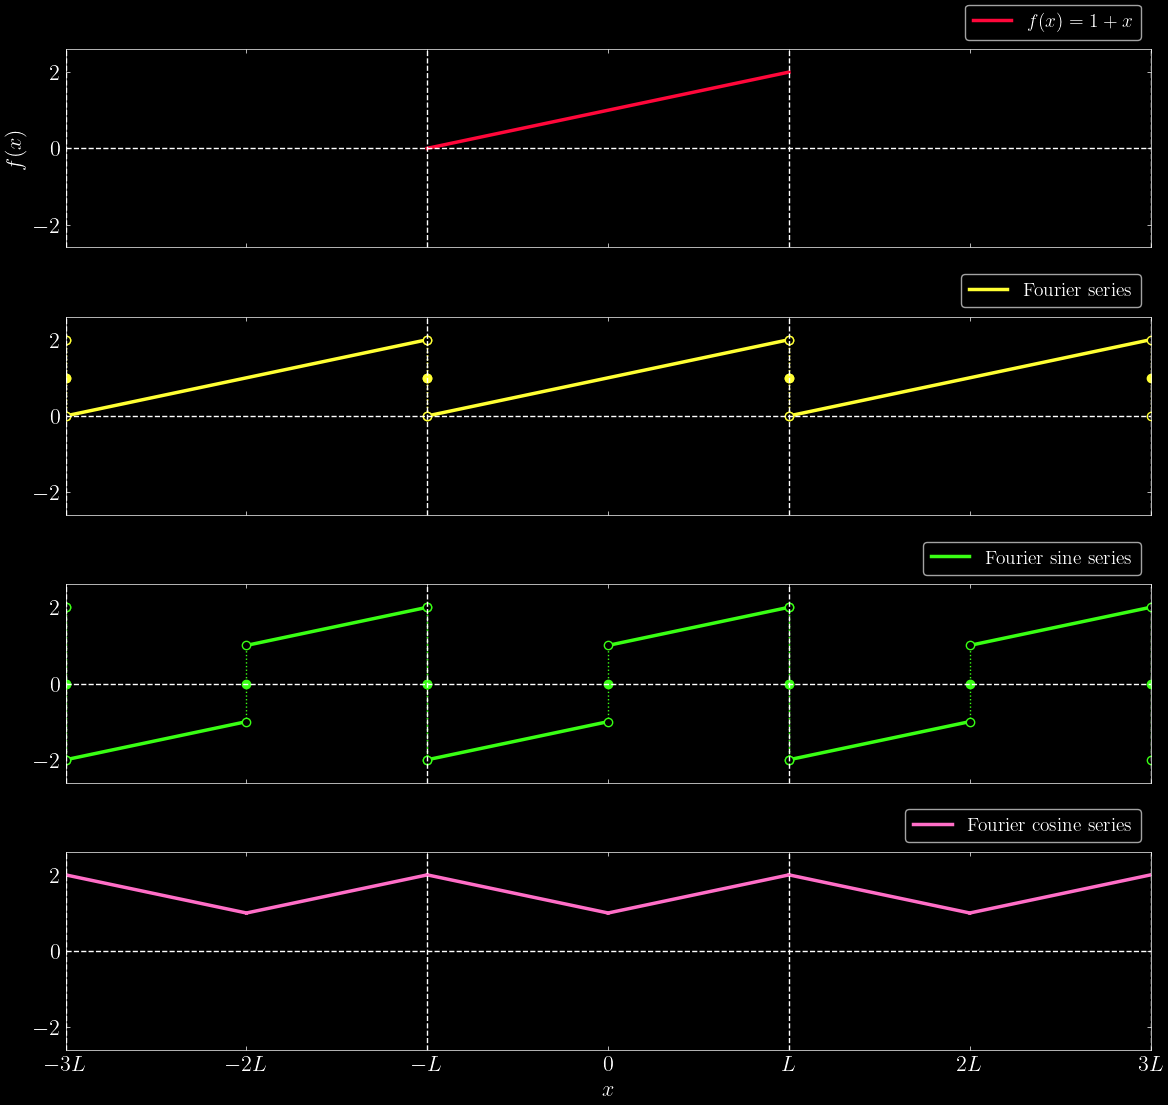

In [5]:
pieces = [(-L, L, lambda x: 1 + x)]
plot_all_series(pieces, r"$f(x) = 1 + x$", "chap3sec3.3ex1b.pdf", ['#FF073A', '#FFFF33', '#39FF14', '#FF6EC7'])

(b) Fourier series: sawtooth, midpoint $1$ at $x = \pm L$. Sine series: odd extension $1 + x$ on $(0, L)$, $-1 + x$ on $(-L, 0)$; jumps at $x = 0$ (midpoint $0$) and $x = \pm L$ (midpoint $0$). Cosine series: even extension $1 + |x|$, continuous everywhere, corners at $x = 0, \pm L$.

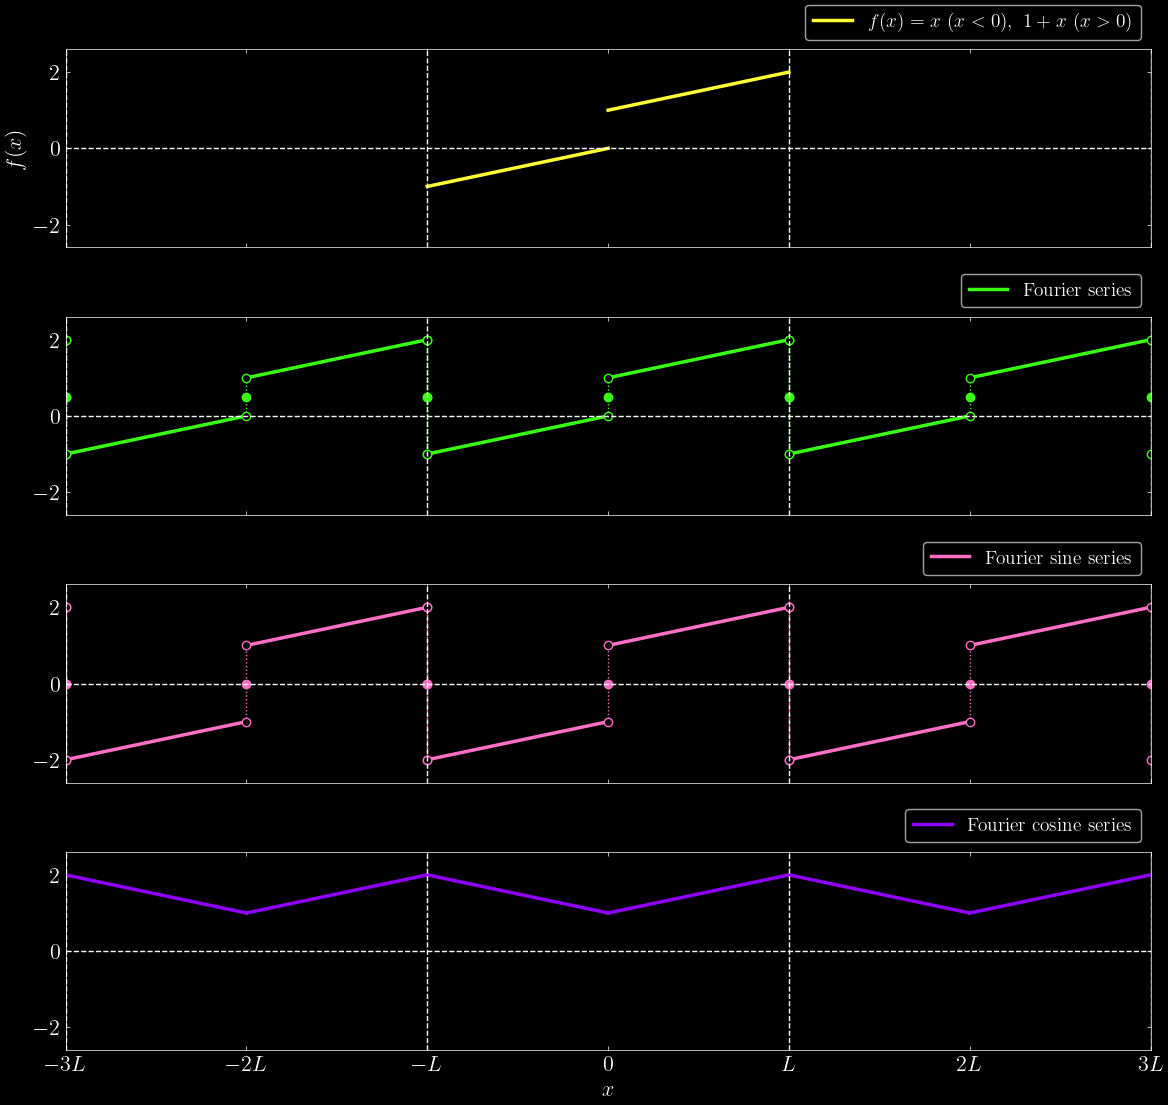

In [6]:
pieces = [(-L, 0, lambda x: x), (0, L, lambda x: 1 + x)]
plot_all_series(pieces, r"$f(x) = x\ (x<0),\ 1 + x\ (x>0)$", "chap3sec3.3ex1c.pdf", ['#FFFF33', '#39FF14', '#FF6EC7', '#8F00FF'])

(c) Fourier series: jump at $x = 0$ (midpoint $1/2$) and at $x = \pm L$ from $1 + L$ to $-L$ (midpoint $1/2$). Sine and cosine series use only $1 + x$ on $(0, L)$, so they are identical to those of part (b).

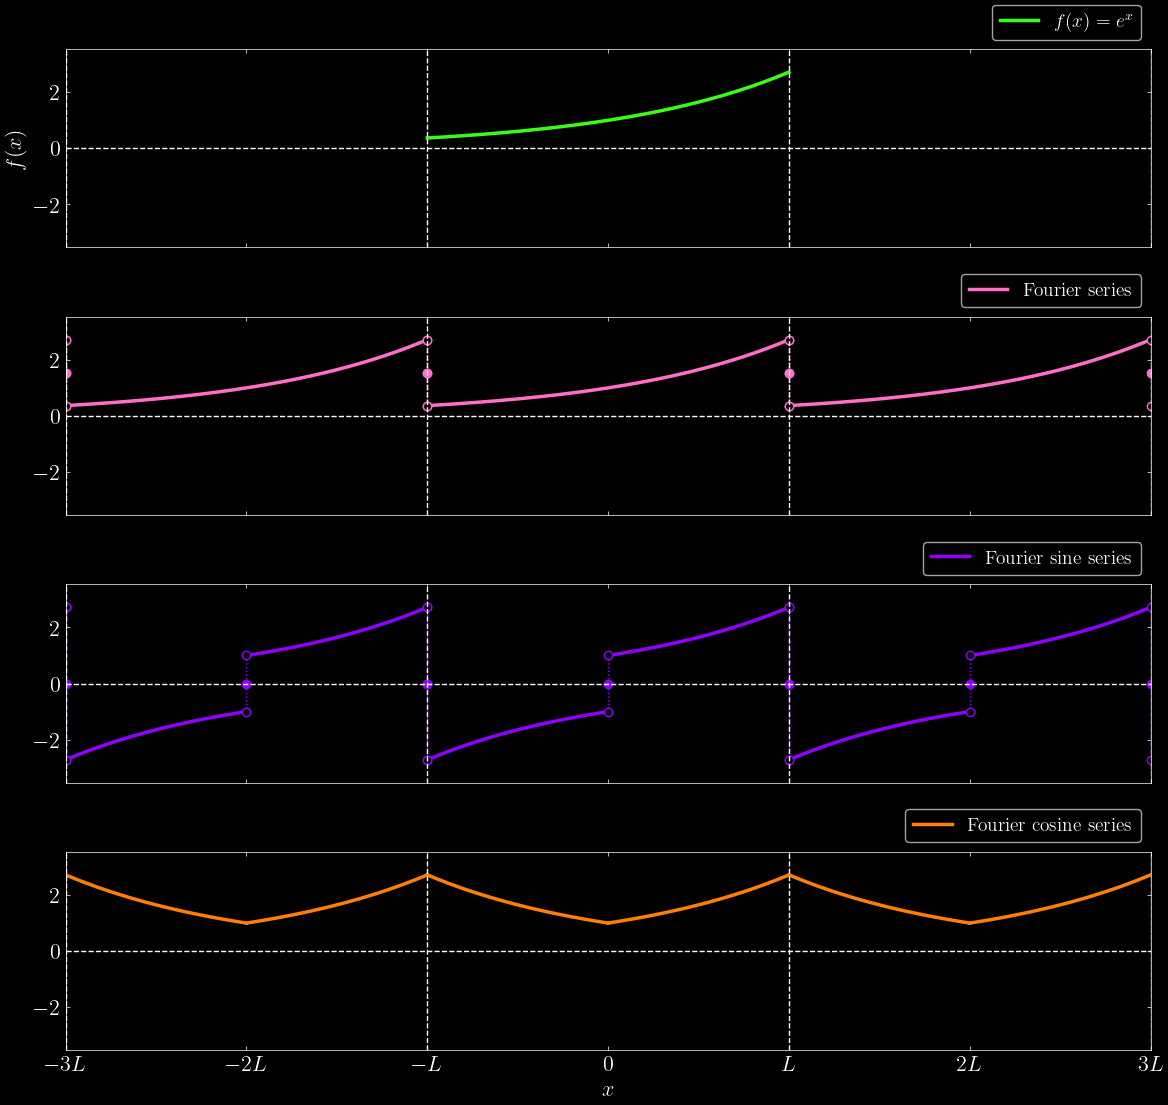

In [7]:
pieces = [(-L, L, lambda x: np.exp(x))]
plot_all_series(pieces, r"$f(x) = e^{x}$", "chap3sec3.3ex1d.pdf", ['#39FF14', '#FF6EC7', '#8F00FF', '#FF7F00'])

(d) Fourier series: jump at $x = \pm L$, midpoint $\cosh L$. Sine series: odd extension $\mathrm{sgn}(x)\, e^{|x|}$; jumps at $x = 0$ and $x = \pm L$, midpoint $0$. Cosine series: even extension $e^{|x|}$, continuous, corners at $x = 0, \pm L$.

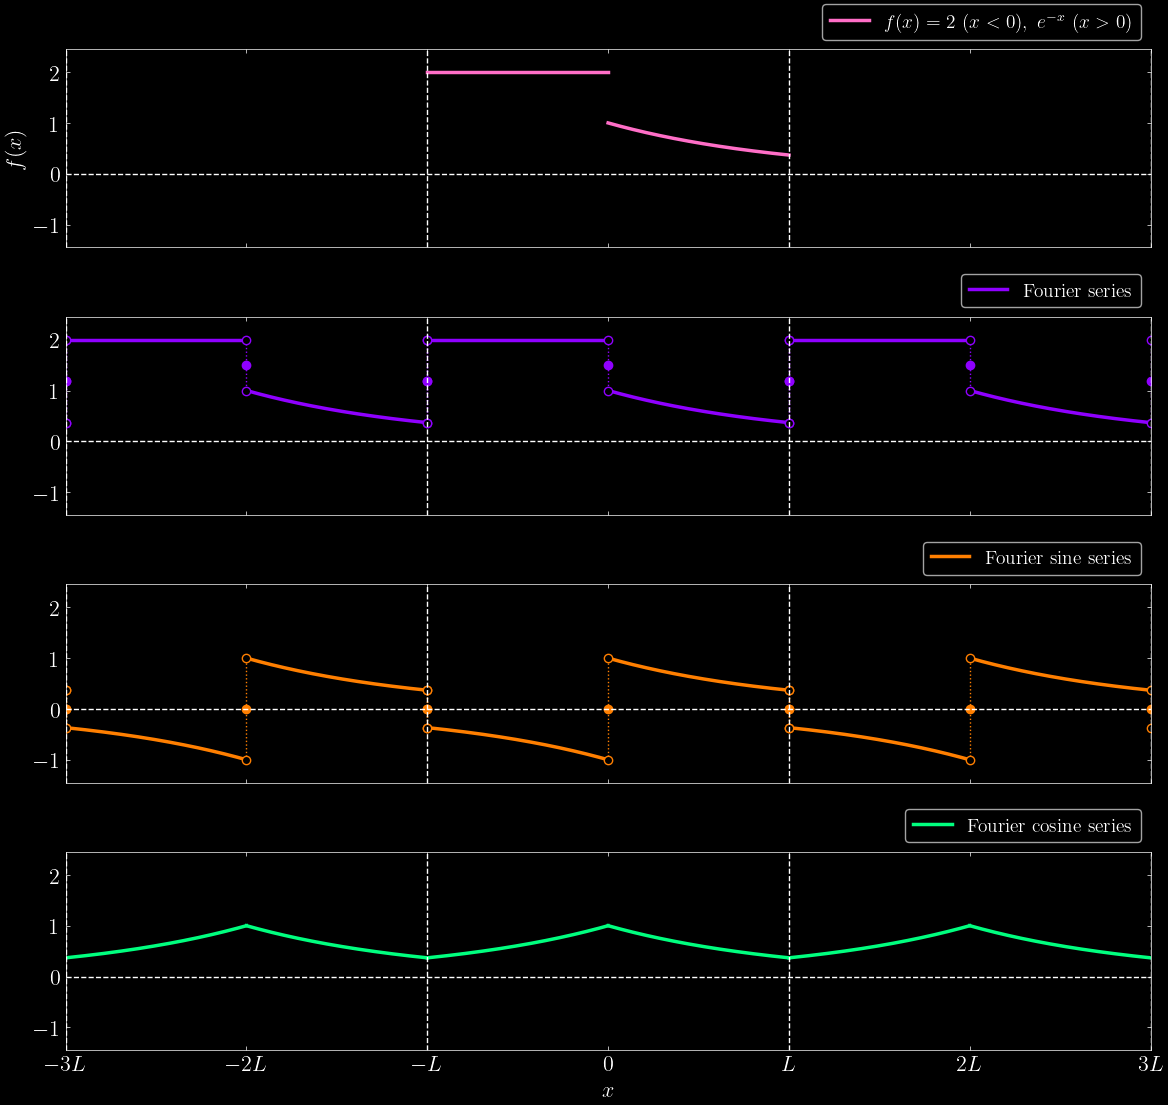

In [8]:
pieces = [(-L, 0, lambda x: 2*np.ones_like(x)), (0, L, lambda x: np.exp(-x))]
plot_all_series(pieces, r"$f(x) = 2\ (x<0),\ e^{-x}\ (x>0)$", "chap3sec3.3ex1e.pdf", ['#FF6EC7', '#8F00FF', '#FF7F00', '#00FF7F'])

(e) Fourier series: jump at $x = 0$ from $2$ to $1$ (midpoint $3/2$) and at $x = \pm L$ from $e^{-L}$ to $2$ (midpoint $1 + e^{-L}/2$). Sine series: odd extension $\mathrm{sgn}(x)\, e^{-|x|}$; jumps at $x = 0$ (midpoint $0$) and $x = \pm L$ (midpoint $0$). Cosine series: even extension $e^{-|x|}$, continuous, corners at $x = 0, \pm L$.